In [60]:
from PIL import Image
from openai import OpenAI
import base64

from langchain_openai import ChatOpenAI
import numpy as np
from IPython.display import Image, display
import yt

In [46]:
image_path = "image/fracture.png"

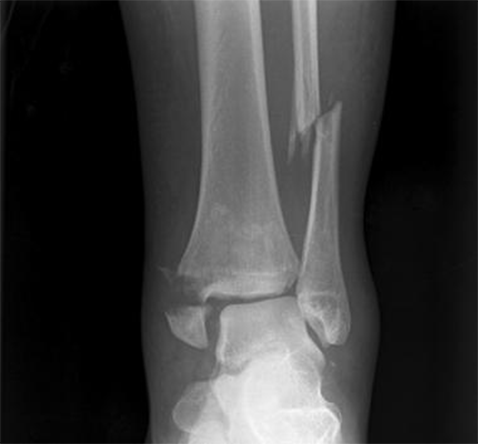

In [58]:
display(Image(filename=image_path))

In [48]:
with open(image_path, "rb") as f:
    image_bytes = f.read()

In [49]:
image_b64 = base64.b64encode(image_bytes).decode("utf-8")
image_data_url = f"data:image/jpeg;base64,{image_b64}"

In [50]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    max_tokens=512,
)

In [51]:
def call(sys_msg, human_msg, image_data_url):
    lc_response = llm.invoke(
        [
            {
                "role": "system",
                "content": sys_msg
            },
            
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {"url": image_data_url}
                    },
                    {
                        "type": "text",
                        "text": human_msg
                    }
                ]
            }
        ]
    )

    return lc_response.content

In [52]:
r = call("You are a precise scientific image analysis assistant and medicine", "Provide a detailed explanation of this image.", image_data_url)
print(r)

This image is an X-ray of a lower leg, specifically showing the tibia and fibula near the ankle joint. 

### Key Features:

1. **Anatomy**:
   - The **tibia** is the larger bone located medially (toward the center of the body), while the **fibula** is the thinner bone situated laterally (toward the outside of the body).
   - The **ankle joint** (talocrural joint) is visible at the distal end between the tibia and fibula, articulating with the talus bone of the foot.

2. **Fracture**:
   - There is a clear indication of a fracture in the vicinity of the fibula. The fracture may appear as a distinct line or break in the continuity of the fibular shaft.
   - The fracture may be classified as either a complete fracture (where the bone is broken into two or more pieces) or an incomplete fracture (where the bone is cracked but not separated).

3. **Soft Tissue**:
   - Surrounding soft tissue may show signs of swelling or other injuries, but this is generally not visible on a standard X-ray.


In [54]:
def load_raw_volume(path, shape=(256, 256, 256), dtype=np.uint8):
    """Load a 3D volume from a headerless RAW file."""
    num_voxels = np.prod(shape)
    
    with open(path, "rb") as f:
        data = np.frombuffer(f.read(), dtype=dtype)
    
    if data.size != num_voxels:
        raise ValueError(
            f"File size does not match expected volume size: "
            f"got {data.size}, expected {num_voxels}"
        )
    
    return data.reshape(shape)

In [55]:
vol = load_raw_volume("3d_datasets/skull_256x256x256_uint8.raw")
print(vol.shape, vol.dtype)

(256, 256, 256) uint8


In [62]:
type(vol)

numpy.ndarray

In [70]:
def create_yt_data(vol):
   data = {("stream", "density"): vol}
    bbox = np.array([[0, 1], [0, 1], [0, 1]])
    
    ds = yt.load_uniform_grid(
        data=data,
        domain_dimensions=vol.shape,
        bbox=bbox,
        nprocs=1,
    ) 

    return ds

IndentationError: unexpected indent (3675789993.py, line 3)

In [68]:
# Load data into yt

data = {("stream", "density"): vol}
bbox = np.array([[0, 1], [0, 1], [0, 1]])

ds = yt.load_uniform_grid(
    data=data,
    domain_dimensions=vol.shape,
    bbox=bbox,
    nprocs=1,
)

yt : [INFO     ] 2025-12-12 15:11:34,083 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-12-12 15:11:34,083 Parameters: domain_dimensions         = [256 256 256]
yt : [INFO     ] 2025-12-12 15:11:34,085 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-12-12 15:11:34,085 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-12-12 15:11:34,086 Parameters: cosmological_simulation   = 0


yt : [INFO     ] 2025-12-12 15:12:41,824 Rendering scene (Can take a while).
yt : [INFO     ] 2025-12-12 15:12:41,825 Creating volume
yt : [INFO     ] 2025-12-12 15:12:42,396 Creating transfer function
yt : [INFO     ] 2025-12-12 15:12:42,396 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


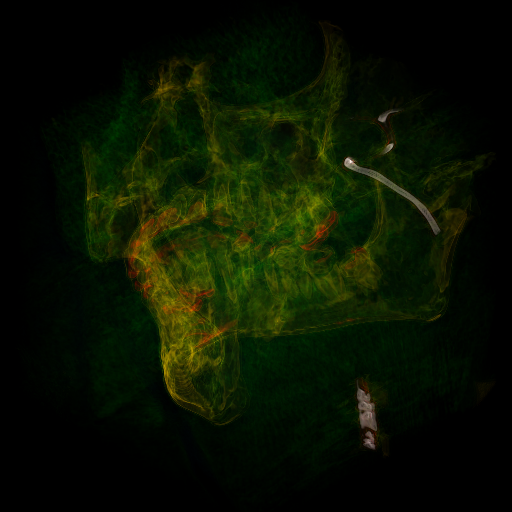

yt : [WARNING  ] 2025-12-12 15:12:44,134 Previously rendered image exists, but rendering anyway. Supply 'render=False' to save previously rendered image directly.
yt : [INFO     ] 2025-12-12 15:12:44,134 Rendering scene (Can take a while).
yt : [INFO     ] 2025-12-12 15:12:45,660 Saving rendered image to image/custom_render.png


In [69]:
sc = yt.create_scene(ds, field=("stream", "density"))
sc.show()
sc.save("image/custom_render.png")